# **1. Import Libraries**

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# **2. Load Dataset**

In [24]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# **3. Data Cleaning**

In [26]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [27]:
df['Income'].fillna(df['Income'].median(), inplace=True)

# **Feature Engineering**

In [28]:
df['Age'] = 2026 - df['Year_Birth']

df['Total_Spending'] = (
      df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

# **Remove Unnecessary Columns**

In [29]:
df.drop(
    ['ID','Year_Birth','Dt_Customer'],
    axis=1,
    inplace=True
)

# **4. One Hot Encoding**

In [30]:
df = pd.get_dummies(
    df,
    columns=[
        'Education',
        'Marital_Status'
    ],
    drop_first=True
)

In [31]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


# **5. Feature Scaling**

In [32]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# **6. Principal Component Analysis**

In [34]:
pca = PCA(n_components=0.95)

pca_data = pca.fit_transform(scaled_data)

print("Original Features:", scaled_data.shape[1])
print("PCA Components:", pca_data.shape[1])

Original Features: 37
PCA Components: 27


# **7. Elbow Method**

In [35]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(pca_data)

    wcss.append(model.inertia_)

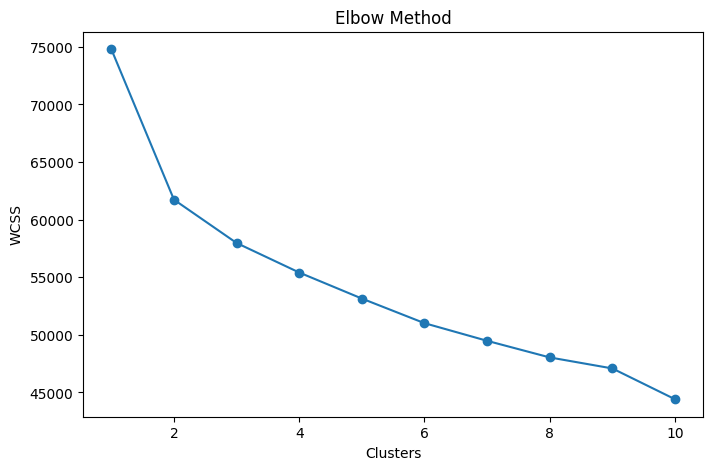

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')

plt.show()

# **8. Silhouette Score**

In [37]:
scores = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pca_data)

    score = silhouette_score(
        pca_data,
        labels
    )

    scores.append(score)

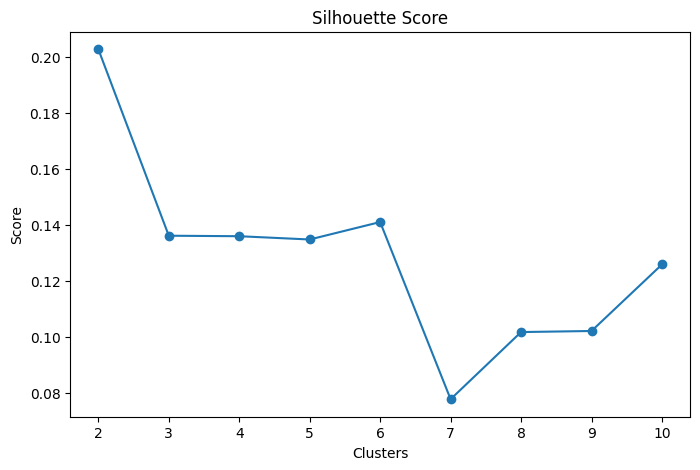

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Clusters')
plt.ylabel('Score')

plt.show()

# **9. K-Means Clustering**

In [39]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_data)

df['Cluster'] = clusters

# **10. PCA Visualization**

In [40]:
pca_vis = PCA(n_components=2)

vis = pca_vis.fit_transform(scaled_data)

vis_df = pd.DataFrame(
    vis,
    columns=['PC1','PC2']
)

vis_df['Cluster'] = clusters

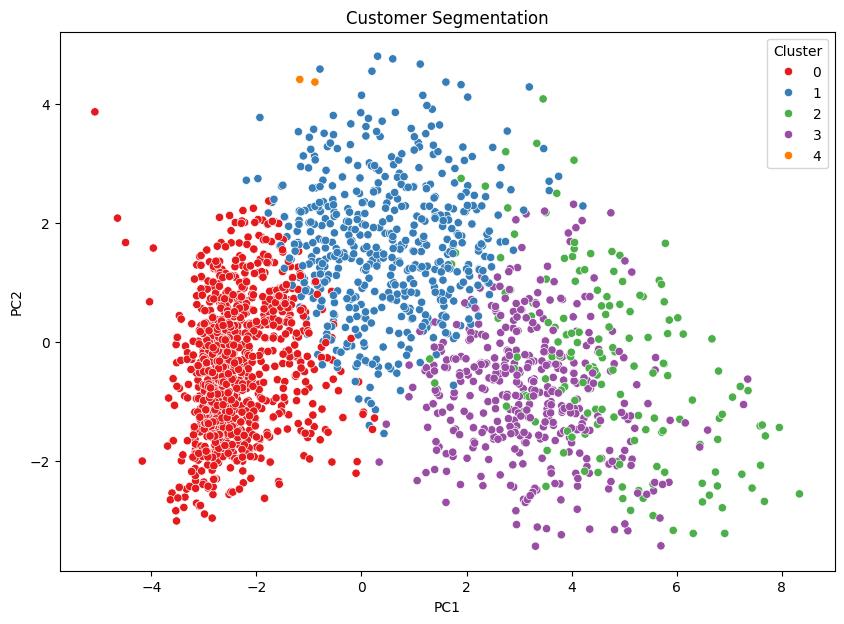

In [41]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=vis_df,
    palette='Set1'
)

plt.title('Customer Segmentation')
plt.show()

# **11. Cluster Profiling**

In [42]:
cluster_profile = df.groupby(
    'Cluster'
).mean()

cluster_profile

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
Cluster,,,,,,,,,,,,,,,,,,,,,
0,35209.129981,0.791271,0.446869,49.605313,43.157495,5.147059,23.867173,7.525617,5.174573,15.655598,...,0.499051,0.160342,0.184061,0.001898,0.094877,0.392789,0.230550,0.255218,0.024668,0.0
1,57830.034843,0.226481,0.933798,47.855401,460.494774,20.907666,132.890244,28.137631,22.001742,59.844948,...,0.437282,0.210801,0.292683,0.001742,0.132404,0.393728,0.165505,0.266551,0.040070,0.0
2,81382.132948,0.052023,0.127168,49.277457,888.369942,55.173410,468.283237,76.491329,64.242775,77.722543,...,0.502890,0.173410,0.254335,0.000000,0.086705,0.416185,0.196532,0.242775,0.052023,0.0
3,74444.459954,0.050343,0.235698,49.704805,495.816934,73.089245,438.032037,106.940503,71.894737,78.322654,...,0.601831,0.114416,0.178490,0.000000,0.093822,0.347826,0.247140,0.265446,0.043478,0.0
4,48432.000000,0.000000,1.000000,3.000000,322.000000,3.000000,50.000000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0


# **12. Customer Personas**

In [43]:
personas = {

    0: 'Low-Value Customers',

    1: 'Budget-Conscious Customers',

    2: 'Value-Oriented Customers',

    3: 'Premium Loyal Customers',

    4: 'Elite High-Value Customers'
}

df['Persona'] = df['Cluster'].map(personas)

# **13. Export Results**

In [44]:
df.to_csv(
    'customer_segments.csv',
    index=False
)

cluster_profile.to_csv(
    'cluster_profiles.csv'
)

# **14. Business Insights**

In [45]:
print(df.groupby('Persona')[
    ['Income',
     'Total_Spending']
].mean())

                                  Income  Total_Spending
Persona                                                 
Budget-Conscious Customers  57830.034843      724.277003
Elite High-Value Customers  48432.000000      424.000000
Low-Value Customers         35209.129981      100.527514
Premium Loyal Customers     74444.459954     1264.096110
Value-Oriented Customers    81382.132948     1630.283237
